In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.metrics import Recall, Precision
from sklearn.metrics import classification_report, f1_score
import tensorflow.keras.backend as K

In [908]:
df_train = pd.read_csv('/content/train.csv')
df_test = pd.read_csv('/content/test.csv')

In [909]:
print("Train Shape:", df_train.shape)
print("Test Shape:", df_test.shape)

Train Shape: (3800, 18)
Test Shape: (950, 17)


In [910]:
print("Train Head:")
print(df_train.head())

print("\nTest Head:")
print(df_test.head())

Train Head:
  patient_id admission_date   age gender  admission_type  \
0   PID10000     2020-01-01  24.0      M               1   
1   PID10001     01/01/2020  73.0      F               1   
2   PID10002     01/01/2020  65.0      F               1   
3   PID10003     2020-01-01  49.0      M               2   
4   PID10004     2020-01-02  49.0      F               1   

   discharge_destination discharge_day_of_week  length_of_stay_days  \
0                      1                   Tue                  1.8   
1                      1                   Thu                 14.7   
2                      3                   Wed                 10.6   
3                      1                   Fri                  9.1   
4                      1                   Thu                  7.5   

   charlson_comorbidity_index  prior_admissions_1yr  n_medications_discharge  \
0                         7.0                   6.0                        2   
1                         2.0           

In [911]:
print("Train Info:")
df_train.info()

print("\nTest Info:")
df_test.info()

Train Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   patient_id                  3800 non-null   object 
 1   admission_date              3800 non-null   object 
 2   age                         3800 non-null   float64
 3   gender                      3800 non-null   object 
 4   admission_type              3800 non-null   int64  
 5   discharge_destination       3800 non-null   int64  
 6   discharge_day_of_week       3800 non-null   object 
 7   length_of_stay_days         3800 non-null   float64
 8   charlson_comorbidity_index  3800 non-null   float64
 9   prior_admissions_1yr        3800 non-null   float64
 10  n_medications_discharge     3800 non-null   int64  
 11  insurance_type              3800 non-null   object 
 12  glucose_level_mgdl          3127 non-null   float64
 13  blood_pressure_systol

In [912]:
print("Train Describe:")
print(df_train.describe())

print("\nTest Describe:")
print(df_test.describe())

Train Describe:
               age  admission_type  discharge_destination  \
count  3800.000000     3800.000000            3800.000000   
mean     56.566842        1.542105               1.656579   
std      56.968099        0.658486               0.923051   
min      18.000000        1.000000               1.000000   
25%      35.000000        1.000000               1.000000   
50%      53.000000        1.000000               1.000000   
75%      72.000000        2.000000               2.000000   
max     999.000000        3.000000               4.000000   

       length_of_stay_days  charlson_comorbidity_index  prior_admissions_1yr  \
count          3800.000000                 3800.000000           3800.000000   
mean              7.247921                    2.268421              2.152105   
std               4.816102                    2.271643              2.133976   
min               1.000000                    0.000000              0.000000   
25%               4.000000        

In [913]:
train_cols = set(df_train.columns)
test_cols = set(df_test.columns)

print("Columns in Train but NOT in Test:", train_cols - test_cols)
print("Columns in Test but NOT in Train:", test_cols - train_cols)

Columns in Train but NOT in Test: {'readmitted_30d'}
Columns in Test but NOT in Train: set()


In [914]:
df_train.drop('patient_id', axis=1, inplace=True)
df_test.drop('patient_id', axis=1, inplace=True)

In [915]:
def extract_date_parts(date):
    if '-' in date:
        parts = date.split('-')
        return int(parts[0]), int(parts[1]), int(parts[2])  # year, month, day
    elif '/' in date:
        parts = date.split('/')
        return int(parts[2]), int(parts[1]), int(parts[0])
    else:
        return None, None, None

df_train[['year','month','day']] = df_train['admission_date'].apply(
    lambda x: pd.Series(extract_date_parts(str(x)))
)

df_test[['year','month','day']] = df_test['admission_date'].apply(
    lambda x: pd.Series(extract_date_parts(str(x)))
)

In [916]:
df_train.drop('admission_date', axis=1, inplace=True)
df_test.drop('admission_date', axis=1, inplace=True)

In [917]:
df_train.loc[df_train['age'] > 100, 'age'] = np.nan
df_test.loc[df_test['age'] > 100, 'age'] = np.nan

In [918]:
median_age = df_train['age'].median()

df_train['age'] = df_train['age'].fillna(median_age)
df_test['age'] = df_test['age'].fillna(median_age)

In [919]:
print("Train data: \n" , df_train.isnull().sum())
print("Test data: \n" , df_test.isnull().sum())

Train data: 
 age                             0
gender                          0
admission_type                  0
discharge_destination           0
discharge_day_of_week           0
length_of_stay_days             0
charlson_comorbidity_index      0
prior_admissions_1yr            0
n_medications_discharge         0
insurance_type                  0
glucose_level_mgdl            673
blood_pressure_systolic         0
sodium_meql                     0
creatinine_mgdl                 0
haemoglobin_gdl                 0
readmitted_30d                  0
year                            0
month                           0
day                             0
dtype: int64
Test data: 
 age                             0
gender                          0
admission_type                  0
discharge_destination           0
discharge_day_of_week           0
length_of_stay_days             0
charlson_comorbidity_index      0
prior_admissions_1yr            0
n_medications_discharge         0
insuranc

In [920]:
# glucose_level_mgdl have 15% around missing values in train and 17% around in test

# Compute median ONLY from train
glucose_median = df_train['glucose_level_mgdl'].median()

df_train['glucose_level_mgdl'] = df_train['glucose_level_mgdl'].fillna(glucose_median)
df_test['glucose_level_mgdl'] = df_test['glucose_level_mgdl'].fillna(glucose_median)

In [921]:
print("Duplicate rows in training set:", df_train.duplicated().sum())
print("Duplicate rows in testing set:", df_test.duplicated().sum())

Duplicate rows in training set: 0
Duplicate rows in testing set: 0


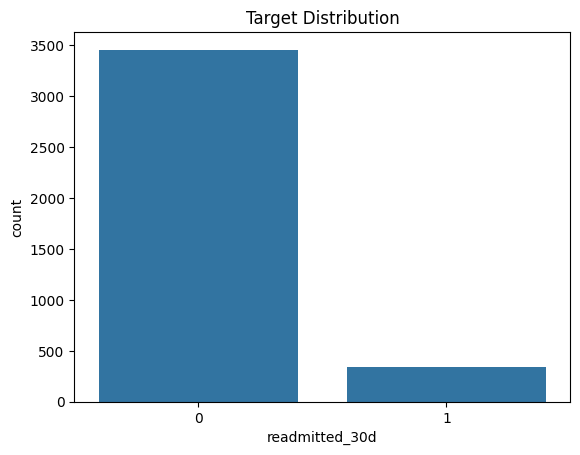

readmitted_30d
0    3458
1     342
Name: count, dtype: int64


In [922]:
sns.countplot(x='readmitted_30d', data = df_train)
plt.title("Target Distribution")
plt.show()

print(df_train['readmitted_30d'].value_counts())

In [923]:
num_cols = df_train.select_dtypes(include=['float64', 'int64']).columns
num_cols = num_cols.drop('readmitted_30d')

def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[col] < lower) | (df[col] > upper)]

for col in num_cols:
    outliers = detect_outliers(df_train, col)
    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
admission_type: 0 outliers
discharge_destination: 207 outliers
length_of_stay_days: 174 outliers
charlson_comorbidity_index: 227 outliers
prior_admissions_1yr: 127 outliers
n_medications_discharge: 0 outliers
glucose_level_mgdl: 57 outliers
blood_pressure_systolic: 479 outliers
sodium_meql: 23 outliers
creatinine_mgdl: 123 outliers
haemoglobin_gdl: 26 outliers
year: 0 outliers
month: 0 outliers
day: 0 outliers


In [924]:
skewness = df_train.skew(numeric_only=True)
print(skewness.sort_values(ascending=False))

readmitted_30d                2.866444
length_of_stay_days           2.121131
creatinine_mgdl               1.484140
charlson_comorbidity_index    1.309134
prior_admissions_1yr          1.208892
discharge_destination         1.147181
admission_type                0.818759
glucose_level_mgdl            0.292357
year                          0.271807
month                         0.214702
sodium_meql                   0.064203
age                           0.021368
day                           0.017579
haemoglobin_gdl               0.012755
n_medications_discharge      -0.045280
blood_pressure_systolic      -1.405373
dtype: float64


In [925]:
log_cols = [
    'length_of_stay_days',
    'creatinine_mgdl',
    'prior_admissions_1yr'
]

for col in log_cols:
    df_train[col] = np.log1p(df_train[col])
    df_test[col] = np.log1p(df_test[col])

In [926]:
high_corr_pairs = []
corr_matrix = df_train.corr(numeric_only=True)

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            high_corr_pairs.append((col1, col2))

print("Highly Correlated Pairs:")
print(high_corr_pairs)

Highly Correlated Pairs:
[('prior_admissions_1yr', 'charlson_comorbidity_index')]


In [927]:
cat_cols = df_train.select_dtypes(include=['object']).columns

for col in cat_cols:
    print(f"\n🔹 Column: {col}")
    print(df_train[col].value_counts())


🔹 Column: gender
gender
M    1935
F    1865
Name: count, dtype: int64

🔹 Column: discharge_day_of_week
discharge_day_of_week
Fri    571
Thu    553
Wed    550
Tue    542
Sat    542
Sun    526
Mon    516
Name: count, dtype: int64

🔹 Column: insurance_type
insurance_type
Medicare     1435
Private      1209
Medicaid      826
Uninsured     330
Name: count, dtype: int64


In [928]:
cat_cols = ['gender', 'discharge_day_of_week', 'insurance_type']

In [929]:
df_train = pd.get_dummies(df_train, columns=cat_cols, drop_first=True)
df_test = pd.get_dummies(df_test, columns=cat_cols, drop_first=True)

In [930]:
X = df_train.drop('readmitted_30d', axis=1)
y = df_train['readmitted_30d']

In [931]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_test = df_test.copy()

In [932]:
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns

In [933]:
binary_cols = [col for col in num_cols if X_train[col].nunique() <= 2]

num_cols = [col for col in num_cols if col not in binary_cols]

In [934]:
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])

In [935]:
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(16, activation='relu'),

    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [936]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))

print(class_weights_dict)

{0: np.float64(0.549530007230658), 1: np.float64(5.547445255474453)}


In [937]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        Recall(name='recall'),
        Precision(name='Precision')
    ]
)

In [938]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weights_dict,
    verbose=1
)

Epoch 1/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - Precision: 0.1745 - loss: 0.5934 - recall: 0.6934 - val_Precision: 0.2218 - val_loss: 0.5530 - val_recall: 0.8971
Epoch 2/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - Precision: 0.2293 - loss: 0.4639 - recall: 0.8394 - val_Precision: 0.2770 - val_loss: 0.4507 - val_recall: 0.8676
Epoch 3/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - Precision: 0.2653 - loss: 0.4050 - recall: 0.8686 - val_Precision: 0.3278 - val_loss: 0.3809 - val_recall: 0.8676
Epoch 4/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Precision: 0.3090 - loss: 0.3747 - recall: 0.8650 - val_Precision: 0.3444 - val_loss: 0.3580 - val_recall: 0.9118
Epoch 5/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Precision: 0.3372 - loss: 0.3619 - recall: 0.8504 - val_Precision: 0.3526 - val_loss: 0.3461 - val_recall: 0.8971
Epoch 6/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Precision: 0.3198 - loss: 0.3543 - recall: 0.8613 - val_Precision: 0.3563 - val_loss: 0.3360 - val_recall: 0.9118
Epo

In [939]:
y_val_prob = model.predict(X_val)

thresholds = np.arange(0.1, 0.6, 0.01)

best_threshold = 0
best_f1 = 0

for t in thresholds:
    y_pred = (y_val_prob > t).astype(int)
    f1 = f1_score(y_val, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best F1 Score:", best_f1)
print(classification_report(y_val, y_pred))

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Best Threshold: 0.5699999999999997
Best F1 Score: 0.5786802030456852
              precision    recall  f1-score   support

           0       0.98      0.90      0.94       692
           1       0.44      0.82      0.57        68

    accuracy                           0.89       760
   macro avg       0.71      0.86      0.75       760
weighted avg       0.93      0.89      0.90       760



In [940]:
y_test_prob = model.predict(X_test)
y_test_pred = (y_test_prob > best_threshold).astype(int)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
